In [8]:
from scipy.io import loadmat
import matplotlib.pyplot as plt
import h5py
import numpy as np
import class_utils as class_utils
from class_grid import Grid
from class_params import Params
from class_groundstate import groundstate
from class_excitations import excitations
from class_vertices import vertices
from class_perturbation import perturbative
from class_self_energy import Self_Energy
from class_io import IO
from class_plotting import plot2D, plot_cns, plot_omega0
import matplotlib.pyplot as plt
from mpl_toolkits.axes_grid1 import make_axes_locatable
import matplotlib.ticker as ticker
from scipy import interpolate

## Compute the continuum ##

In [2]:

config_path = "config.yml" 

output_dir = class_utils.create_output_dir()

config = class_utils.read_config(config_path)

Lx = config["grid"]["Lx"]
Ly = config["grid"]["Ly"]
cutoff = config["physics"]["cutoff"]
N = config["physics"]["N"]
UIB = config["physics"]["UIB"]
M = Lx * Ly

dJUs = np.loadtxt('./ragheed_data/dJU_values_nqcorr_1.csv',delimiter=',',skiprows=1).transpose()
muUs = np.loadtxt('./ragheed_data/muU_values_nqcorr_1.csv',delimiter=',',skiprows=1).transpose()

UIB = config["physics"]["UIB"]
cutoff = config["physics"]["cutoff"]

grid = Grid(Lx, Ly)

epss = np.zeros((len(dJUs), M * cutoff))
omegs = np.zeros((len(dJUs), M * cutoff))
epss_mat = np.zeros((len(dJUs), M * N , M * N))
omega_mat = np.zeros((len(dJUs), M * N, M * N))
pertE = np.zeros(len(dJUs))
dJUs_rep = np.zeros((len(dJUs), M * N))
for dJU_ind in range(0, len(dJUs)):
    dJU = dJUs[dJU_ind]
    muU = muUs[dJU_ind]
    print(dJU)
    params = Params(N, dJU, muU, UIB, cutoff)
    gs = groundstate(params)
    cns = gs.cns()
    n0 = gs.n0(cns)
    psi0 = gs.psi0(cns)
    exc = excitations(grid, params, gs, cns)
    uks, vks, omegaklambda = exc.calculate_matrices()
    verts = vertices(grid, gs, uks, vks, cns, n0)

    # the rayleigh schrodinger result
    pert = perturbative(grid, params, verts, omegaklambda)
    Pert_Energy = pert.perturbative_energy(n0)
    pertE[dJU_ind] = Pert_Energy[0] + Pert_Energy[1] + Pert_Energy[2]

    Epol = 0
    self_energy = Self_Energy(Epol, grid, params, verts, omegaklambda)
    omegs[dJU_ind, :] = self_energy.omega_vec()
    epss[dJU_ind, :] = dJU * self_energy.epsI_vec()
    dJUs_rep[dJU_ind, :] = np.ones(Lx * Ly * N) * dJU

continuum = omegs + epss

0.005025125628140704
0.010050251256281407
0.01507537688442211
0.020100502512562814
0.02512562814070352
0.03015075376884422
0.035175879396984924
0.04020100502512563
0.04522613065326633
0.05025125628140704
0.05527638190954774
0.06030150753768844
0.06532663316582915
0.07035175879396985
0.07537688442211056
0.08040201005025126
0.08542713567839195
0.09045226130653267
0.09547738693467336
0.10050251256281408
0.10552763819095477
0.11055276381909548
0.11557788944723618
0.12060301507537688
0.12562814070351758
0.1306532663316583
0.135678391959799
0.1407035175879397
0.1457286432160804
0.15075376884422112
0.15577889447236182
0.16080402010050251
0.1658291457286432
0.1708542713567839
0.17587939698492464
0.18090452261306533
0.18592964824120603
0.19095477386934673
0.19597989949748745
0.20100502512562815
0.20603015075376885
0.21105527638190955
0.21608040201005024
0.22110552763819097
0.22613065326633167
0.23115577889447236
0.23618090452261306
0.24120603015075376
0.24623115577889448
0.25125628140703515
0.2

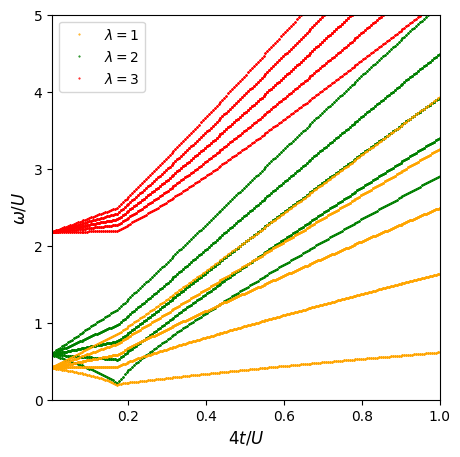

In [6]:
## 1 excitation - 1 impurity continuua
fig, ax1 = plt.subplots(ncols = 1, figsize = (5,5))

msize = 1
for dJU_ind in range(0, len(dJUs)):
    if dJU_ind == 0:
        ax1.plot(dJUs_rep[dJU_ind, 2*M], continuum[dJU_ind, M], '.', color="orange", markersize = msize, label = "$\lambda = 1$")
        ax1.plot(dJUs_rep[dJU_ind, 2*M], continuum[dJU_ind, 2*M], '.', color="green",markersize = msize, label = "$\lambda = 2$")
        ax1.plot(dJUs_rep[dJU_ind, 2*M], continuum[dJU_ind, 3*M], '.', color="red", markersize = msize, label = "$\lambda = 3$")

    
    ax1.plot(dJUs_rep[dJU_ind, 2*M : 3*M], continuum[dJU_ind, 2*M: 3*M ], '.', color="green",markersize = msize)
    ax1.plot(dJUs_rep[dJU_ind, 2*M : 3*M], continuum[dJU_ind, M: 2*M ], '.', color="orange", markersize = msize)
    ax1.plot(dJUs_rep[dJU_ind, 2*M : 3*M], continuum[dJU_ind, 3*M: 4*M ], '.', color="red", markersize = msize)


ax1.set_xlabel(r'$4t/U$', fontsize=12)

ax1.set_ylabel(r'$\omega/U$', fontsize=12)


#ax1.plot(dJUs, pertE, linestyle='--', label='NSC:  Perturbative', color='black', linewidth=1.5)

#fig.suptitle(f"Results 1Exc-1Imp continuum: Mu/U = {muU:0.2f}, UIB/U = {UIB:0.2f}, Total Sites = {M}", fontsize = 10)
ax1.set_ylim(np.min(continuum[:,:4*M]), np.max(continuum[:,:4*M]))
ax1.set_ylim(0,5)

ax1.set_xlim(min(dJUs), max(dJUs))
ax1.legend()

plt.show()


In [7]:
## Save the figure 
filename = f'../figs/continuum/nqcorr_1p0_M_{grid.M}_N_{N}_num_dJU_{len(dJUs)}.pdf'
fig.savefig(filename, dpi=300, bbox_inches='tight')

In [9]:
# interpolate muU values for an input value of dJU
f = interpolate.interp1d(dJUs, muUs)

In [12]:
f(0.2154)

array(0.39158591)